# Projeto: 
# *Prevendo Manuteção de Máquinas Industriais*

#### **Os Dados Foram Anoninizados** `São dados que passaram por um processo para remover ou ocultar qualquer informação que permita identificar uma pessoa ou entidade específica.` 🔐📊

### Definindo e Compreendendo o Problema a Ser Resolvido

* Objetivo: Prever se uma máquina industrial precisa ou não de manutenção através de 178 leituras de dados de sensores IoT (Internet of Things ou Internet das Coisas).

### Compreensão dos Dados

Vamos trabalhar com dados históricos coletados de sensores IoT de máquinas industriais. Os dados são fictícios.

Cada linha do dataset contém 178 leituras, que são as colunas de diferentes sensores. Ou seja, existem 178 colunas que compõem as leituras de sensores IoT. No total, existem 11.500 linhas e 179 colunas com a última coluna contendo o status da máquina industrial, se precisou ou não de manutenção. Os dados ja foram tratados e não será preciso fazer nenhum tipo de limpeza!

`Os dados são fictícios.`

---

### Imports e Instalação de pacotes 

In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Carregando os dados

In [2]:
# Carregando os Dados

df = pd.read_csv('dataset.csv')

In [3]:
# 179 colunas e 11500 linhas

df.shape

(11500, 179)

In [4]:
# Visualizando uma amostra dos dados

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,VARIAVEL_ALVO
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,0
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,0


* Na ultima coluna, o valor 1 representa a classe positiva (a maquina precisou de manuntenção), enquato que o valor 0 representa a classe negativa (a máquina não precisou de manutenção). Esta será nossa variavel alvo

**`O Dataset já esta limpo, dessa forma podemos focar mais na resolução do problema!`**

In [5]:
# Verificando valores ausentes

df.isna().sum().sum()

np.int64(0)

In [6]:
# Checando quantas colunas duplicadas existem no dataset

df.columns.duplicated().sum()

np.int64(0)

In [7]:
# Calculando a prevalência da classe positiva

prevalencia = df['VARIAVEL_ALVO'].mean()
print(f"Prevalência: {prevalencia:.2f}")

Prevalência: 0.20


`20% dos registros pertencem à classe positiva (1).`

### **Importância das Variáveis:**

>Aqui usamos um modelo para descobrir quais sensores são mais importantes para prever manutenção. Usaremos Random Forest.

#### Separando os dados

In [8]:
var_X = df.drop("VARIAVEL_ALVO", axis=1)
var_y = df["VARIAVEL_ALVO"]

#### Treinando modelo:

>O objetivo é explorar os dados e extrair a importância das variáveis.
>
>Vamos treinar o modelo com todo o dataset para descobrir quais variáveis são mais relevantes.

In [9]:
modelo = RandomForestClassifier(n_estimators=200,random_state=42)

modelo.fit(var_X, var_y)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 30 variáveis mais importantes:

In [10]:
var_importante = pd.Series(modelo.feature_importances_, index=var_X.columns).sort_values(ascending=False)

print(var_importante.head(30))

X156    0.020413
X159    0.019563
X28     0.018652
X157    0.018290
X160    0.017527
X158    0.017394
X161    0.015875
X162    0.013525
X45     0.013309
X27     0.012912
X96     0.012327
X17     0.011463
X39     0.011404
X13     0.010948
X95     0.010929
X127    0.010652
X37     0.010562
X92     0.010010
X14     0.009796
X29     0.009591
X169    0.009435
X44     0.009387
X105    0.009370
X93     0.009346
X20     0.009290
X106    0.009287
X19     0.009076
X36     0.008986
X21     0.008720
X108    0.008634
dtype: float64


#### Visualizar sensores mais importantes

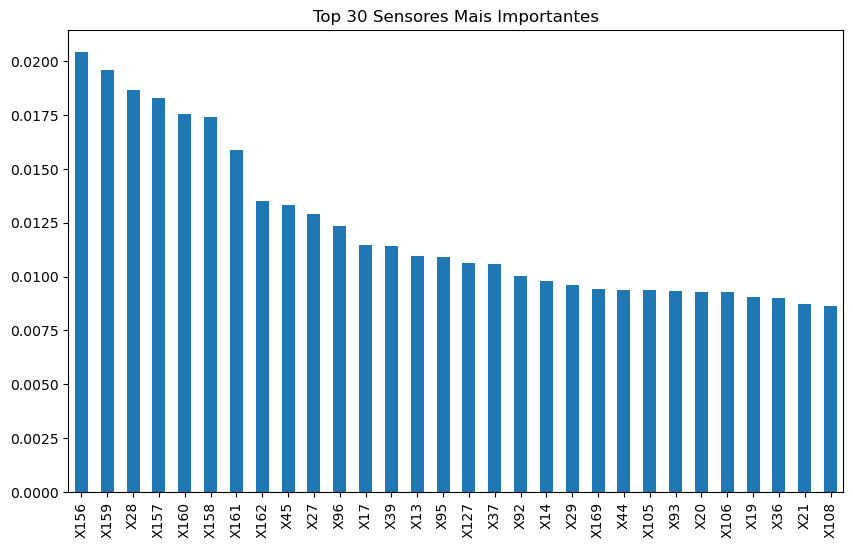

In [11]:
plt.figure(figsize=(10,6))

var_importante.head(30).plot(kind="bar")

plt.title("Top 30 Sensores Mais Importantes")
plt.show()

>>*`Esses sensores são os mais relevantes para prever manutenção da máquina. Podemos fazer um outro projeto apenas com os 30 melhores sensores por exemplo e comparar os resultados`*

---

### Divisão dos dados em treino e teste para Criação dos Modelos de Machine Learning com Todo o Dataset

A divisão de treinamento é usada para treinar nosso algoritmo de aprendizado de máquina, por isso queremos usar a maioria de nosso conjunto de dados. O conjunto de dados de teste é usado para testar a precisão do nosso modelo de aprendizado de máquina.


In [12]:
# SEPARAÇÃO X e Y

X = df.iloc[:, :178]
y = df["VARIAVEL_ALVO"]

In [13]:
# DIVISÃO DOS DADOS 70/30

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

In [14]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (8050, 178)
Teste: (3450, 178)


#### Padronização

In [15]:
# Padronização dos dados (StandardScaler)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### treinando 4 modelos separadamente

In [16]:
# Armazenamento dos resultados!

resultados = []

In [17]:
# LOGISTIC REGRESSION

modelo_lr = LogisticRegression(max_iter=500)

modelo_lr.fit(X_train_scaled, y_train)

preds = modelo_lr.predict(X_test_scaled)
probs = modelo_lr.predict_proba(X_test_scaled)[:,1]

resultados.append({
    "Modelo": "LogisticRegression",
    "AUC": roc_auc_score(y_test, probs),
    "Accuracy": accuracy_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "Precision": precision_score(y_test, preds)
})

In [18]:
# NAIVE BAYES

modelo_nb = GaussianNB()

modelo_nb.fit(X_train_scaled, y_train)

preds = modelo_nb.predict(X_test_scaled)
probs = modelo_nb.predict_proba(X_test_scaled)[:,1]

resultados.append({
    "Modelo": "NaiveBayes",
    "AUC": roc_auc_score(y_test, probs),
    "Accuracy": accuracy_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "Precision": precision_score(y_test, preds)
})

In [19]:
# RANDOM FOREST

modelo_rf = RandomForestClassifier()

modelo_rf.fit(X_train_scaled, y_train)

preds = modelo_rf.predict(X_test_scaled)
probs = modelo_rf.predict_proba(X_test_scaled)[:,1]

resultados.append({
    "Modelo": "RandomForest",
    "AUC": roc_auc_score(y_test, probs),
    "Accuracy": accuracy_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "Precision": precision_score(y_test, preds)
})

In [20]:
# XGBOOST

modelo_xgb = XGBClassifier()

modelo_xgb.fit(X_train_scaled, y_train)

preds = modelo_xgb.predict(X_test_scaled)
probs = modelo_xgb.predict_proba(X_test_scaled)[:,1]

resultados.append({
    "Modelo": "XGBoost",
    "AUC": roc_auc_score(y_test, probs),
    "Accuracy": accuracy_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "Precision": precision_score(y_test, preds)
})

In [21]:
resultados

[{'Modelo': 'LogisticRegression',
  'AUC': 0.5249107330392775,
  'Accuracy': 0.82,
  'Recall': 0.10289855072463767,
  'Precision': 0.9726027397260274},
 {'Modelo': 'NaiveBayes',
  'AUC': 0.9825829657634951,
  'Accuracy': 0.9542028985507246,
  'Recall': 0.8855072463768116,
  'Precision': 0.8855072463768116},
 {'Modelo': 'RandomForest',
  'AUC': 0.9946762759924386,
  'Accuracy': 0.9736231884057971,
  'Recall': 0.9202898550724637,
  'Precision': 0.9463487332339792},
 {'Modelo': 'XGBoost',
  'AUC': 0.994545263600084,
  'Accuracy': 0.9701449275362319,
  'Recall': 0.8942028985507247,
  'Precision': 0.9536321483771252}]

In [22]:
# Tabela com os resultados

df_results = pd.DataFrame(resultados).sort_values("AUC", ascending=False)

df_results

,Modelo,AUC,Accuracy,Recall,Precision
2,RandomForest,0.994676,0.973623,0.920290,0.946349
3,XGBoost,0.994545,0.970145,0.894203,0.953632
1,NaiveBayes,0.982583,0.954203,0.885507,0.885507
0,LogisticRegression,0.524911,0.820000,0.102899,0.972603


>>Iremos Salvar o Melhor Modelo!

In [23]:
# Melhor modelo

melhor = df_results.iloc[0]["Modelo"]
melhor

'RandomForest'

In [24]:
# dicionário com os modelos treinados
modelos = {
    "LogisticRegression": modelo_lr,
    "NaiveBayes": modelo_nb,
    "RandomForest": modelo_rf,
    "XGBoost": modelo_xgb
}

In [25]:
# selecionar o melhor modelo

melhor_modelo = modelos[melhor]
melhor_modelo

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Gravando o modelo

In [26]:
pickle.dump(melhor_modelo, open('melhor_modelo.pkl', 'wb'), protocol =4)

In [27]:
# abrir o arquivo

modelo = pickle.load(open('melhor_modelo.pkl', 'rb'))

#### **Fazendo previsões:**

In [28]:
# Criando novos dados ficticios

'''
Os novos dados precisam ter 178 colunas, exatamente como no treino.
'''

# nova_maquina = pd.DataFrame(np.random.randint(-150,150,(1,178))) # Sem nome nas colunas, elas ficam somente enumeradas
nova_maquina = pd.DataFrame(np.random.randint(-150,150,(1,178)),columns= X.columns)

nova_maquina

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,20,-122,-54,22,22,-17,-58,-107,134,-48,...,103,-100,73,-60,83,-37,-76,-128,-4,-137


In [29]:
# Fazer a previsão

previsao = modelo.predict(nova_maquina)

print("Previsão:", previsao)

Previsão: [1]


**Conclusão:** 

O conjunto de dados já se encontrava previamente limpo e preparado, permitindo que o foco da análise fosse direcionado à construção e avaliação dos modelos preditivos, com o objetivo de identificar o modelo mais adequado para aplicação.

Entre os modelos testados, o Random Forest apresentou o melhor desempenho, destacando-se por possuir o maior valor de AUC, além de apresentar métricas superiores de acurácia e recall em comparação aos demais modelos avaliados.

Como etapa adicional, é possível realizar a otimização de hiperparâmetros para verificar se o Random Forest mantém sua superioridade após o ajuste fino do modelo. Além disso, outra estratégia interessante consiste em treinar o modelo utilizando apenas as variáveis mais relevantes, permitindo comparar os resultados e avaliar possíveis ganhos de desempenho ou simplificação do modelo.

# Fim